<a href="https://colab.research.google.com/github/AditiDalal108/Reco-Sys/blob/user-profile-data-based/Recommender_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
from IPython.display import display, HTML
import numpy as np

In [8]:
import requests
import zipfile
import io

url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"

# Download zip
r = requests.get(url)

# Unzip
zip_file = zipfile.ZipFile(io.BytesIO(r.content))

# See files inside
print(zip_file.namelist())

# Read users
users = pd.read_csv(
    zip_file.open("ml-1m/users.dat"),
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip"]
)

# Read ratings
ratings = pd.read_csv(
    zip_file.open("ml-1m/ratings.dat"),
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

# Read movies
movies = pd.read_csv(
    zip_file.open("ml-1m/movies.dat"),
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)






['ml-1m/', 'ml-1m/movies.dat', 'ml-1m/ratings.dat', 'ml-1m/README', 'ml-1m/users.dat']
Ratings dataset shape : (1000209, 4)


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
print ("Ratings dataset shape :" , ratings.shape)
ratings.head()

In [9]:
print ("Movies dataset shape :" , movies.shape)
movies.head()

Movies dataset shape : (3883, 3)


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [10]:
print ("Users dataset shape :" , users.shape)
users.head()

Users dataset shape : (6040, 5)


,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [11]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)")
movies["title"] = movies["title"].str.replace(r"\(\d{4}\)", "", regex=True).str.strip()
movies['genres'] = movies['genres'].str.split('|')
movies.head( )

,movie_id,title,genres,year
0,1,Toy Story,"[Animation, Children's, Comedy]",1995
1,2,Jumanji,"[Adventure, Children's, Fantasy]",1995
2,3,Grumpier Old Men,"[Comedy, Romance]",1995
3,4,Waiting to Exhale,"[Comedy, Drama]",1995
4,5,Father of the Bride Part II,[Comedy],1995


<Axes: xlabel='genres'>

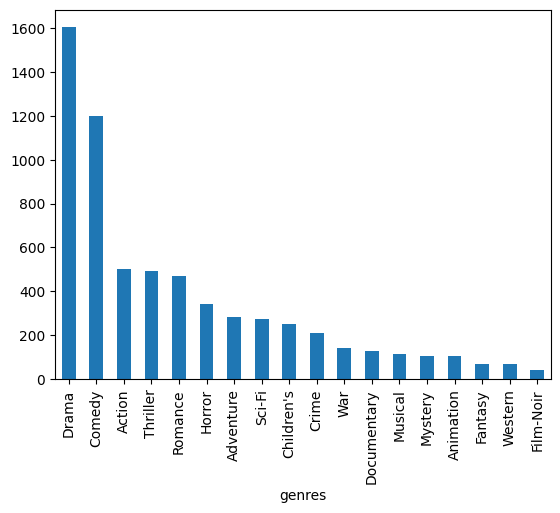

In [16]:
movies['genres'].explode().value_counts().plot(kind = 'bar')

In [18]:
movies['year'].value_counts()

,count
year,
1996,345
1995,342
1998,337
1997,315
1999,283
...,...
1928,3
1919,3
1922,2


In [14]:
print(ratings['timestamp'] .dtype)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'],unit = 's')
print(ratings['timestamp'] .dtype)

int64
datetime64[ns]


User Interaction Matrix

In [19]:


display(HTML("<h1>User - Movie Interation Matrix</h1>"))

matrix = ratings.pivot_table(index='user_id', columns='movie_id', values='rating', fill_value=0, aggfunc = 'mean')
matrix


movie_id,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,0.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
#Sparsity
sparsity = round(1.0 - np.count_nonzero(matrix) / matrix.size,2)
print ("Sparsity of the Interaction matrix is :" + str(sparsity * 100) + "%")

Sparsity of the Interaction matrix is :96.0%
